In [1]:
# # NOTEBOOK NAME
# # McCoyWeather.ipynb
# # NOTEBOOK NAME

# # OPENING IMPORTS
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

import matplotlib.cm as cm
import matplotlib.colors as mcolors

import matplotlib.dates as mdates
from scipy.ndimage import gaussian_filter

In [2]:
temps = pd.read_csv('/home/563/sg3241/McCoyTdailyMeans.csv')

In [3]:
# count days below 10 C

# Convert DateTime column from string to datetime (if not already done)
temps['DateTime'] = pd.to_datetime(temps['DateTime'])

# Filter for temperatures below 10°C
below_10 = temps[temps['Mean'] < 10].copy()

# Sort by DateTime to ensure consecutive days are in order
below_10 = below_10.sort_values('DateTime').reset_index(drop=True)

# Calculate the difference in days between consecutive rows
below_10['DayDiff'] = below_10['DateTime'].diff().dt.days

# Create a group identifier for consecutive day blocks
# A new block starts when the day difference is not 1 (or is NaN for the first row)
below_10['Block'] = (below_10['DayDiff'] != 1).fillna(True).cumsum()

# Group by block and get the first DateTime and count of days in each block
result = below_10.groupby('Block').agg(
    DateTime=('DateTime', 'first'),
    DaysCount=('DateTime', 'count')
).reset_index(drop=True)

print(result)

      DateTime  DaysCount
0   2006-05-21          1
1   2006-06-05          2
2   2006-06-08          3
3   2006-06-12          2
4   2006-06-19          2
..         ...        ...
179 2025-08-13          1
180 2026-05-07          1
181 2026-06-22          1
182 2026-06-27          2
183 2026-07-05          7

[184 rows x 2 columns]


In [4]:
result_sorted = result.sort_values('DaysCount').reset_index(drop=True)

(array([95., 54., 18., 10.,  3.,  0.,  3.,  0.,  1.]),
 array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]),
 <BarContainer object of 9 artists>)

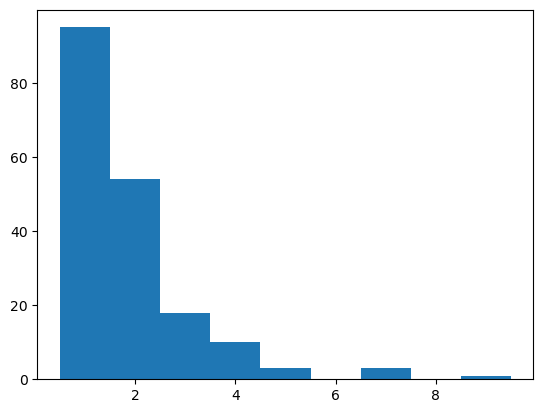

In [5]:
plt.hist(result_sorted['DaysCount'][:],bins=np.arange(0.5, 10.5, 1))

In [6]:
result_sorted 

,DateTime,DaysCount
0,2012-07-29,1
1,2013-07-31,1
2,2013-07-25,1
3,2018-08-26,1
4,2013-06-26,1
...,...,...
179,2013-07-07,5
180,2008-07-21,7
181,2026-07-05,7
182,2019-06-19,7


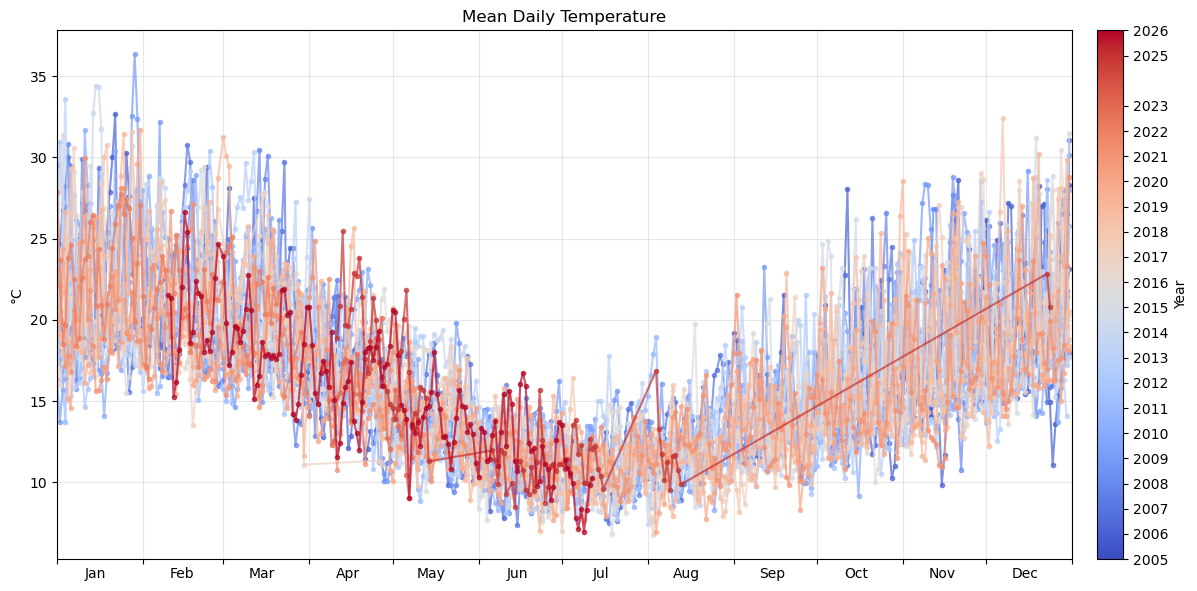

In [7]:

# Convert DateTime column from string to datetime
temps['DateTime'] = pd.to_datetime(temps['DateTime'])
temps['Year'] = temps['DateTime'].dt.year

# Normalise all dates to the same dummy year (2000 - a leap year)
temps['NormalisedDate'] = temps['DateTime'].apply(
    lambda dt: dt.replace(year=2000)
)

# Set up blue-to-red colourmap across years
years = sorted(temps['Year'].unique())
norm = mcolors.Normalize(vmin=min(years), vmax=max(years))
cmap = cm.coolwarm

# Create the plot
fig, ax = plt.subplots(figsize=(13, 6))

# Plot each year with a colour from the colourmap
for year in years:
    year_data = temps[temps['Year'] == year]
    colour = cmap(norm(year))
    ax.plot(year_data['NormalisedDate'], year_data['Mean'],
            color=colour, marker='o', markersize=3, alpha=0.7)

# --- X-axis: ticks and grid at month borders, labels in the middle ---

# Ticks and grid lines at the 1st of each month (+ Jan of next year to close off Dec)
month_borders = [pd.Timestamp(f'2000-{m:02d}-01') for m in range(1, 13)] + \
                [pd.Timestamp('2001-01-01')]
ax.set_xticks(month_borders)
ax.set_xticklabels([])  # Hide the border tick labels

# Add month name labels manually at the midpoint of each month
mid_month_dates = [pd.Timestamp(f'2000-{m:02d}-15') for m in range(1, 13)]
for mid in mid_month_dates:
    ax.text(mid, -0.015, mid.strftime('%b'),
            ha='center', va='top', transform=ax.get_xaxis_transform())

# Grid lines at month borders only
ax.xaxis.grid(True, alpha=0.3)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# Set x-axis limits
ax.set_xlim(pd.Timestamp('2000-01-01'), pd.Timestamp('2001-01-01'))

# --- Colourbar legend outside the plot on the right ---
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required dummy call
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Year')
cbar.set_ticks(years)
cbar.set_ticklabels([str(y) for y in years])

plt.ylabel('°C')
plt.title('Mean Daily Temperature')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



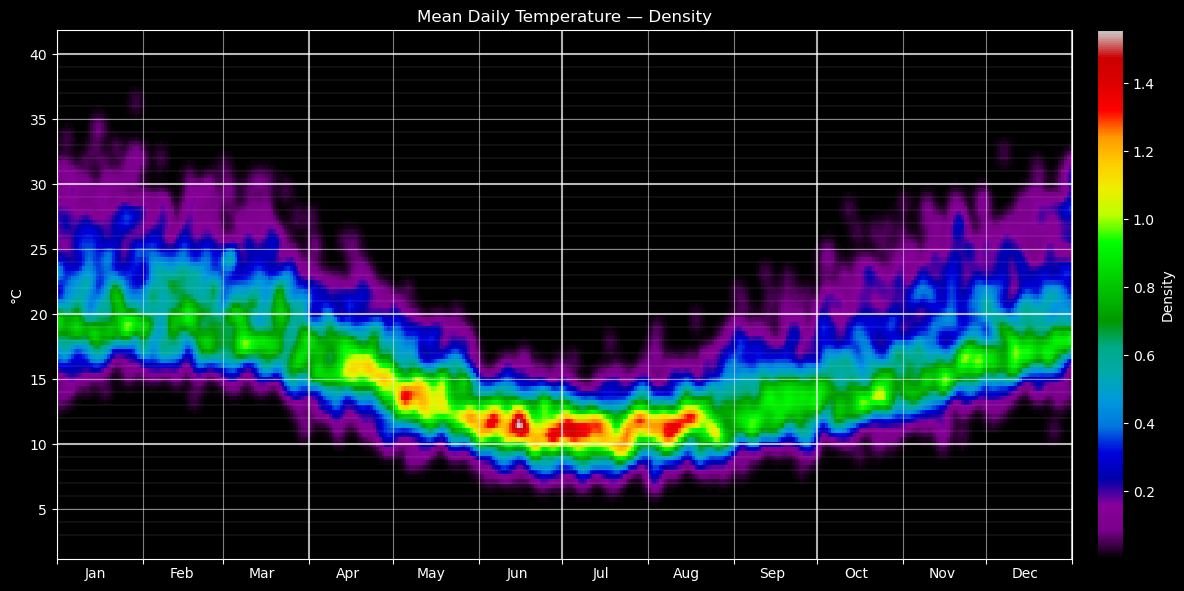

In [8]:

# Convert DateTime column from string to datetime
temps['DateTime'] = pd.to_datetime(temps['DateTime'])
temps['Year'] = temps['DateTime'].dt.year

# Normalise all dates to the same dummy year (2000 - a leap year)
temps['NormalisedDate'] = temps['DateTime'].apply(
    lambda dt: dt.replace(year=2000)
)

# Convert NormalisedDate to numeric for binning
temps['DateNumeric'] = temps['NormalisedDate'].astype(np.int64)

# Define bin edges
n_date_bins = 366
n_temp_bins = 100

date_bins = np.linspace(
    pd.Timestamp('2000-01-01').value,
    pd.Timestamp('2001-01-01').value,
    n_date_bins + 1
)

# Pad the temp range so Gaussian blur can fade out smoothly at the edges
temp_padding = 3
temp_bins = np.linspace(
    temps['Mean'].min() - temp_padding,
    temps['Mean'].max() + temp_padding,
    n_temp_bins + 1
)

# Compute 2D histogram
density, _, _ = np.histogram2d(
    temps['DateNumeric'], temps['Mean'],
    bins=[date_bins, temp_bins]
)
density = density.T  # Transpose so rows = temp, cols = date

# Apply Gaussian blur to create smooth density appearance
density = gaussian_filter(density, sigma=[2, 2])

# Only mask truly empty bins
density[density == 0] = np.nan

# Convert bin edges back to Timestamps for the x-axis
date_bin_edges = pd.to_datetime(date_bins)

# Create the plot with black background
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

mesh = ax.pcolormesh(
    date_bin_edges, temp_bins, density,
    cmap='nipy_spectral', shading='flat', zorder=1
)

# Colourbar for density
cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label('Density', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

# --- Layered grid lines (zorder=2 to sit on top of mesh) ---

temp_min = int(np.floor(temps['Mean'].min() - temp_padding))
temp_max = int(np.ceil(temps['Mean'].max() + temp_padding))
all_int_degrees = np.arange(temp_min, temp_max + 1)

# Thin lines for all integer degrees
for t in all_int_degrees:
    ax.axhline(t, color='white', linewidth=0.3, alpha=0.3, zorder=2)

# Medium lines for 5, 15, 25, ... (odd multiples of 5)
for t in all_int_degrees:
    if t % 10 == 5 or t % 10 == -5:
        ax.axhline(t, color='white', linewidth=0.8, alpha=0.5, zorder=2)

# Thick lines for every 10 degrees (0, 10, 20, ...)
for t in all_int_degrees:
    if t % 10 == 0:
        ax.axhline(t, color='white', linewidth=1.5, alpha=0.7, zorder=2)

# Vertical grid lines at month borders
month_borders = [pd.Timestamp(f'2000-{m:02d}-01') for m in range(1, 13)] + \
                [pd.Timestamp('2001-01-01')]
quarter_months = {1, 4, 7, 10}  # Jan, Apr, Jul, Oct

for i, mb in enumerate(month_borders):
    month_num = mb.month if mb.year == 2000 else 1  # handle 2001-01-01
    if month_num in quarter_months:
        ax.axvline(mb, color='white', linewidth=1.5, alpha=0.7, zorder=2)
    else:
        ax.axvline(mb, color='white', linewidth=0.8, alpha=0.5, zorder=2)

# --- X-axis labels in the middle of each month ---
ax.set_xticks(month_borders)
ax.set_xticklabels([])

mid_month_dates = [pd.Timestamp(f'2000-{m:02d}-15') for m in range(1, 13)]
for mid in mid_month_dates:
    ax.text(mid, -0.015, mid.strftime('%b'),
            ha='center', va='top', transform=ax.get_xaxis_transform(),
            color='white')

ax.set_xlim(pd.Timestamp('2000-01-01'), pd.Timestamp('2001-01-01'))

# Style axes for black background
ax.tick_params(colors='white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')

plt.ylabel('°C')
plt.title('Mean Daily Temperature — Density')
plt.tight_layout()
plt.show()


In [9]:
# CHAD FUNCTION TO STORE TRAILING MEANS

def consecutive_rolling_mean(df, days, date_col='DateTime', value_col='Mean'):
    """
    Calculates a rolling mean over `days` consecutive days.
    Only calculates a value if all `days` preceding days (inclusive) have data.
    Returns a new DataFrame with the last day as the date and the rolling mean.

    Parameters
    ----------
    df   : DataFrame containing date and value columns
    days : int, number of consecutive days to average over
    """

    # Ensure sorted by date and work on a clean copy
    df = df.copy().sort_values(date_col).reset_index(drop=True)

    # Normalise to date only (no time component) for gap checking
    df['_date'] = pd.to_datetime(df[date_col]).dt.normalize()

    results = []

    for i in range(len(df)):
        # We need `days` rows ending at row i
        if i < days - 1:
            continue

        window = df.iloc[i - days + 1 : i + 1]

        # Check all dates in the window are consecutive (no gaps)
        date_diffs = window['_date'].diff().dropna()
        all_consecutive = (date_diffs == pd.Timedelta(days=1)).all()

        if all_consecutive:
            results.append({
                date_col: df.loc[i, date_col],
                f'{days}-Day Mean': window[value_col].mean()
            })

    result_df = pd.DataFrame(results).reset_index(drop=True)
    return result_df

In [10]:
Means3 = consecutive_rolling_mean(temps,3)
Means5 = consecutive_rolling_mean(temps,5)
Means7 = consecutive_rolling_mean(temps,7)
Means10 = consecutive_rolling_mean(temps,10)

In [11]:
temps_sorted = temps.sort_values('Mean').reset_index(drop=True)


In [16]:
Means5_sorted = Means5.sort_values('7-Day Mean').reset_index(drop=True)

In [18]:
Means7_sorted

,DateTime,7-Day Mean
0,2026-07-11,8.334122
1,2026-07-12,8.383307
2,2026-07-10,8.442447
3,2007-07-22,8.507165
4,2007-07-21,8.605379
...,...,...
5795,2009-02-01,27.908115
5796,2014-01-19,27.918315
5797,2013-03-12,28.186230
5798,2009-02-03,28.238542


In [ ]:
fig, ax = plt.subplots()

ax.hist(temps['Mean'], bins=np.arange(0, 41, 1),
        color='orange', edgecolor='red', linewidth=0.8,
        rwidth=0.85)  # rwidth < 1 adds a small gap between bars

# Grid every 5 degrees (vertical lines)
ax.set_xticks(np.arange(0, 41, 5))
ax.xaxis.grid(True, alpha=0.5)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

ax.set_xlabel('Mean Temperature (°C)')
ax.set_ylabel('Number of Days')
ax.set_title('Distribution of Mean Daily Temperature')

plt.xlim([0,40])

plt.tight_layout()
plt.show()



In [ ]:
fig, ax = plt.subplots()

ax.hist(Means3['3-Day Mean'], bins=np.arange(0, 41, 1),
        color='yellow', edgecolor='orange', linewidth=0.8,
        rwidth=0.85)  # rwidth < 1 adds a small gap between bars

# Grid every 5 degrees (vertical lines)
ax.set_xticks(np.arange(0, 41, 5))
ax.xaxis.grid(True, alpha=0.5)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

ax.set_xlabel('Mean Temperature (°C)')
ax.set_ylabel('Number of Days')
ax.set_title('Distribution of 3-Day Mean Daily Temperature')

plt.xlim([0,40])

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots()

ax.hist(Means5['5-Day Mean'], bins=np.arange(0, 41, 1),
        color='green', edgecolor='blue', linewidth=0.8,
        rwidth=0.85)  # rwidth < 1 adds a small gap between bars

# Grid every 5 degrees (vertical lines)
ax.set_xticks(np.arange(0, 41, 5))
ax.xaxis.grid(True, alpha=0.5)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

ax.set_xlabel('Mean Temperature (°C)')
ax.set_ylabel('Number of Days')
ax.set_title('Distribution of 5-Day Mean Daily Temperature')

plt.xlim([0,40])

plt.tight_layout()
plt.show()

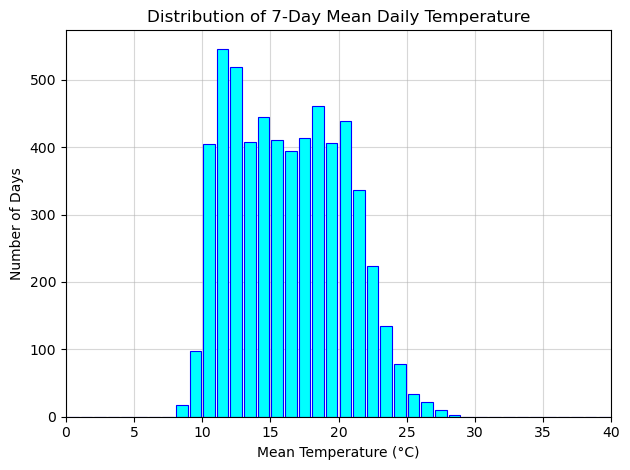

In [15]:
fig, ax = plt.subplots()

ax.hist(Means7['7-Day Mean'], bins=np.arange(0, 41, 1),
        color='cyan', edgecolor='blue', linewidth=0.8,
        rwidth=0.85)  # rwidth < 1 adds a small gap between bars

# Grid every 5 degrees (vertical lines)
ax.set_xticks(np.arange(0, 41, 5))
ax.xaxis.grid(True, alpha=0.5)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

ax.set_xlabel('Mean Temperature (°C)')
ax.set_ylabel('Number of Days')
ax.set_title('Distribution of 7-Day Mean Daily Temperature')

plt.xlim([0,40])

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots()

ax.hist(Means10['10-Day Mean'], bins=np.arange(0, 41, 1),
        color='purple', edgecolor='blue', linewidth=0.8,
        rwidth=0.85)  # rwidth < 1 adds a small gap between bars

# Grid every 5 degrees (vertical lines)
ax.set_xticks(np.arange(0, 41, 5))
ax.xaxis.grid(True, alpha=0.5)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

ax.set_xlabel('Mean Temperature (°C)')
ax.set_ylabel('Number of Days')
ax.set_title('Distribution of 10-Day Mean Daily Temperature')

plt.xlim([0,40])

plt.tight_layout()
plt.show()